# Heart Disease Prediction Using Machine Learning

## Step 1: Load and Explore Dataset

## Step 2: Data Preprocessing

## Step 3: Feature Engineering

## Step 4: Model Training

## Step 5: Model Evaluation

## Step 6: Conclusion

In [1]:
import pandas as pd

df = pd.read_csv('heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)


Shape: (1025, 14)

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [4]:
# Check duplicate records

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 723


In [5]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (302, 14)


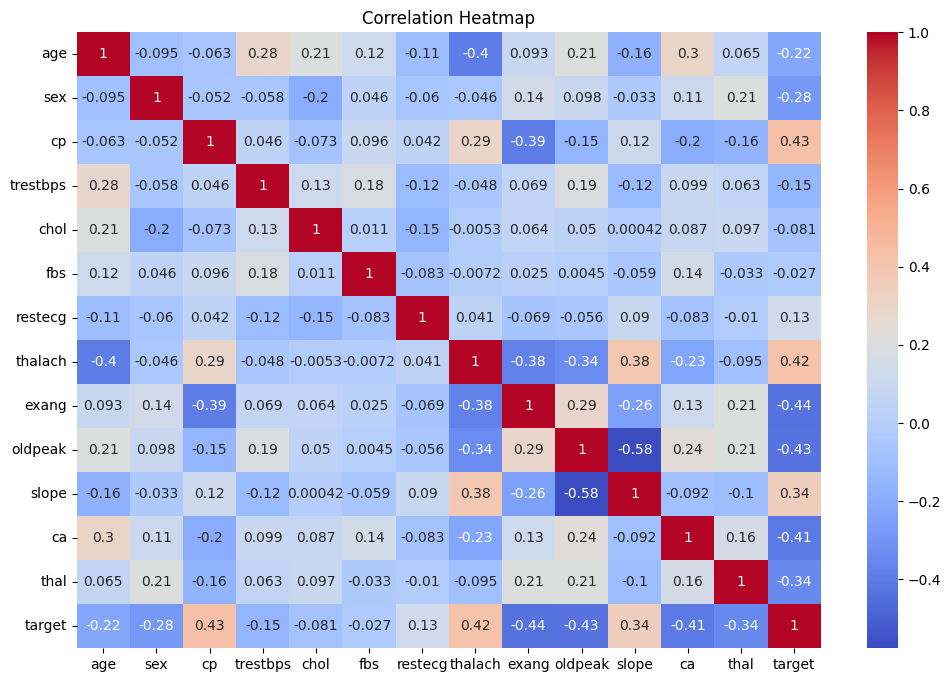

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [7]:
corr = df.corr()['target'].sort_values(ascending=False)

print(corr)

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64


### Data Preprocessing Summary

The dataset contained 723 duplicate records which were removed.

The dataset size reduced from 1025 rows to 302 rows.

No missing values were present in the dataset.

Removing duplicates improves model quality and prevents biased predictions.

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (241, 13)
Testing Shape: (61, 13)


In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Trained Successfully")

Logistic Regression Trained Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Trained Successfully")

KNN Trained Successfully


In [12]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

def evaluate(y_true, pred):

    accuracy = accuracy_score(y_true, pred)
    precision = precision_score(y_true, pred)
    recall = recall_score(y_true, pred)
    f1 = f1_score(y_true, pred)

    return [accuracy, precision, recall, f1]

In [13]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "KNN"
    ],

    "Accuracy": [
        evaluate(y_test, lr_pred)[0],
        evaluate(y_test, rf_pred)[0],
        evaluate(y_test, knn_pred)[0]
    ],

    "Precision": [
        evaluate(y_test, lr_pred)[1],
        evaluate(y_test, rf_pred)[1],
        evaluate(y_test, knn_pred)[1]
    ],

    "Recall": [
        evaluate(y_test, lr_pred)[2],
        evaluate(y_test, rf_pred)[2],
        evaluate(y_test, knn_pred)[2]
    ],

    "F1 Score": [
        evaluate(y_test, lr_pred)[3],
        evaluate(y_test, rf_pred)[3],
        evaluate(y_test, knn_pred)[3]
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.786885,0.722222,0.896552,0.800000
1,Random Forest,0.852459,0.794118,0.931034,0.857143
2,KNN,0.639344,0.581395,0.862069,0.694444


In [14]:
results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.852459,0.794118,0.931034,0.857143
0,Logistic Regression,0.786885,0.722222,0.896552,0.800000
2,KNN,0.639344,0.581395,0.862069,0.694444


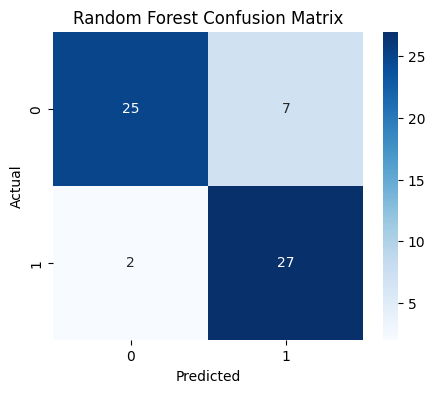

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Conclusion

In this project, a Heart Disease Prediction system was developed using Machine Learning.

The dataset was cleaned by removing duplicate records and analyzed using correlation analysis.

Three machine learning models were trained: Logistic Regression, Random Forest, and KNN.

Random Forest achieved the highest accuracy of 85.25%, making it the best-performing model.

This project demonstrates how machine learning can assist in predicting heart disease using patient health data.